# Lab 1: Gradient Descent

**Student: Viktoriia Vlasenko, 2088928**

In [2]:

%matplotlib inline

# some imports

import numpy as np # import the package numpy and assign an alias called 'np' (numpy is a package for scientific computing)
import matplotlib.pyplot as plt #import the package 'matplotlib.pyplot' and assign the alias plt

from numpy.linalg import norm # from package numpy.linalg import the function 'norm'


# Exercise 1

## Gradient descent in 2 dimensions
Here, we want to implement gradient descent to minimize a strongly convex function in 2 dimensions. In particular, for $\eta > 1$,  we consider the following target function $f : \mathbb{R}^2 \to \mathbb{R}$
$$
f(x) :=  \frac{1}{2} \left(x_1^2 + \eta x_2^2 \right),
$$
where $x_i$ denotes the $i$-th entry of $x$.

Thus, we start implementing the function $f$.



In [2]:
eta = 1 # consider for instance the setting with eta = 1
def f(x): # define a function called 'f' which takes a parameter x
  # x has to be a bi-dimensional vector
  return (x[0] ** 2 + eta * x[1] ** 2) / 2

Since the input space is 2-dimensional, we can visualize it with a contour plot.

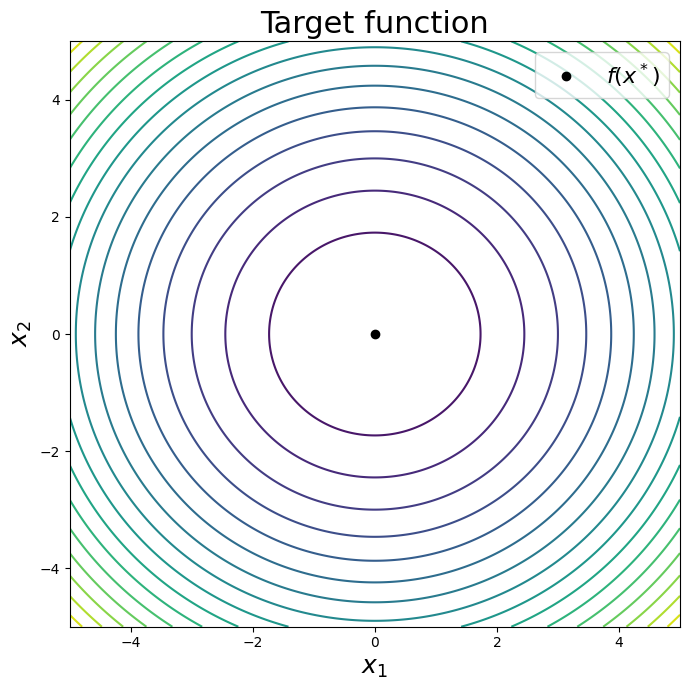

In [3]:
x1 = np.linspace(-5, 5, 1000)
x2 = np.linspace(-5, 5, 1000)

X1, X2 = np.meshgrid(x1, x2)
Y = (X1 ** 2 + eta * X2 ** 2) / 2

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.set_title("Target function", fontsize=22)
ax.contour(X1, X2, Y, levels=20)
ax.plot(0, 0, 'o', c='black', label="$f(x^*)$")

ax.legend(fontsize=16)
ax.set_xlabel("$x_1$", fontsize=18)
ax.set_ylabel("$x_2$", fontsize=18)
fig.tight_layout()




Now, we focus on implementing the gradient descent (GD) iteration to solve the problem i.e.
$$
x_{k + 1} = x_k - \gamma \nabla f(x_k)
$$
where $\gamma$ is the step-size. Thus, to implement such a procedure, we have to:

- Implement the gradient of the target $\nabla f (\cdot)$.
- Compute the step-size $\gamma$.

Since the target depends from a parameter $\eta$, we can implement a function that builds the target and its gradient given an $\eta$.

In [11]:
def build_target(eta):

  def f(x):
    return 1/2 * (x[0] ** 2 + eta * x[1] ** 2)

  def grad_f(x):
    # TODO: return the gradient of the target function on the given point x
    return np.array([x[0], eta * x[1]])

  # it returns the target function and the gradient function
  return f, grad_f

Since the target function is smooth and strongly-convex, we have that gradient descent converges linearly for
$$
0 < \gamma < \frac{2}{L},
$$
where $L$ is the Lipschitz constant of the gradient (note that $L = \eta$). Now, we can implement gradient descent procedure.

In [23]:
def gradient_descent(x0, eta, gamma, max_iters = 10):
  f, grad_f = build_target(eta) # get target and its gradient
  x_obs = np.empty((max_iters, 2)) # matrix with size max_iters x 2 used to store the minimizer estimates
  f_obs = np.empty(max_iters) # vector with size max_iters used to store function values
  x = x0.copy()
  for k in range(max_iters):
    x_obs[k] = x
    f_obs[k] = f(x)
    x = x_obs[k] - gamma * grad_f(x_obs[k]) # TODO: compute the iteration
  # returns the last estimate, the history of all estimates and function values
  return x, x_obs, f_obs

Then, given an initial guess $x_0$, we compute the stepsize $\gamma$ and we run gradient descent for some iterations (e.g. $20$).

In [56]:
x0 = np.array([5.0, 5.0]) # initial estimate
eta = 10 # arbitrary choice of eta

mu = 1
L = eta
gamma = 2 / L # TODO: compute the stepsize
max_iters = 20

x, x_obs, f_obs = gradient_descent(x0, eta, gamma, max_iters=max_iters) # TODO: run gradient descent

We can define a function to plot function values

In [28]:
def plot_function_values(f_vals):
  fig, ax = plt.subplots(1, 1, figsize=(10, 7))
  ax.plot(range(f_vals.shape[0]), f_vals, '-', color='black', lw=2, label="$f$")
  ax.set_xlabel("$k$", fontsize=18)
  ax.set_ylabel("$f(x_k)$", fontsize=18)
  ax.set_yscale("log") # set logarithmic scale for y-axis
  ax.legend(fontsize=18)

Now, we can plot the function values

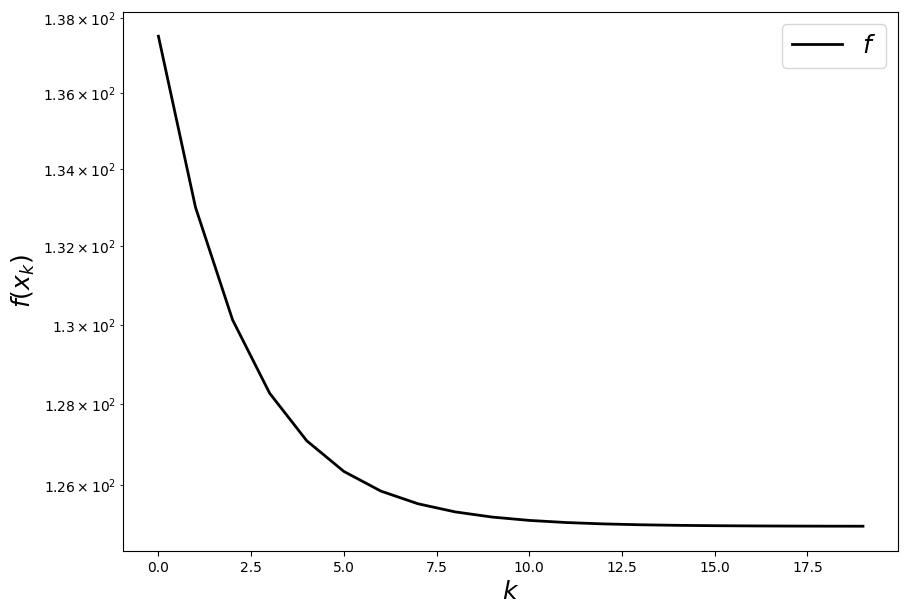

In [57]:
plot_function_values(f_obs)

To observe the behavior of GD, we can define a function to plot the trajectory in a contour plot

In [58]:
def plot_trajectory(x_obs):
  bounds = [-7 , 7]
  x1 = np.linspace(bounds[0], bounds[1], 1000)
  x2 = np.linspace(bounds[0], bounds[1], 1000)

  X1, X2 = np.meshgrid(x1, x2)
  Y = (X1 ** 2 + eta * X2 ** 2) / 2

  fig, ax = plt.subplots(1, 1, figsize=(10, 7))
  ax.set_title("GD trajectory", fontsize=22)
  ax.contour(X1, X2, Y, levels=20)

  x_prev = x_obs[0]
  for i in range(1, x_obs.shape[0]):
    x = np.clip(x_obs[i], [bounds[0], bounds[0]], [bounds[1], bounds[1]]) # to keep fixed the plot size, we clip the iterate
    ax.plot(x_prev[0], x_prev[1], 'o', c='black', ms=7)
    ax.annotate("", xy=(x[0], x[1]), xytext=(x_prev[0], x_prev[1]), arrowprops=dict(arrowstyle='->', ls='--', lw=2.0))
    x_prev = x

  ax.plot(0.0, 0.0, 'o', c='red')
  ax.set_xlabel("$x_1$", fontsize=18)
  ax.set_ylabel("$x_2$", fontsize=18)
  fig.tight_layout()

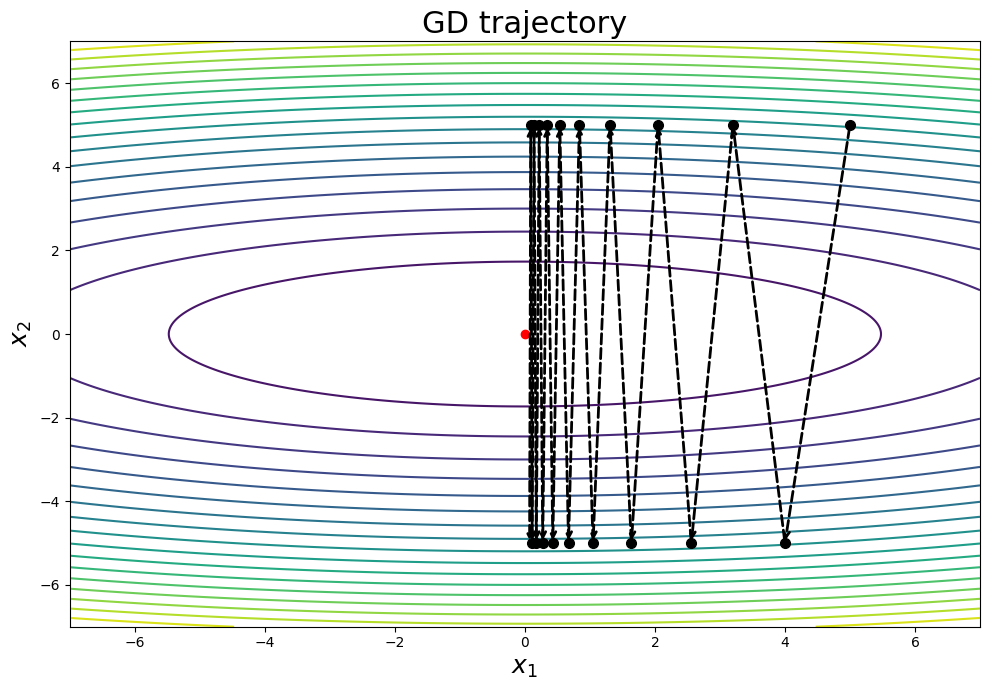

In [59]:
plot_trajectory(x_obs)

Change the stepsize and observe how the trajectory changes

$ 0.18181818181818182 <= gamma < 0.2$

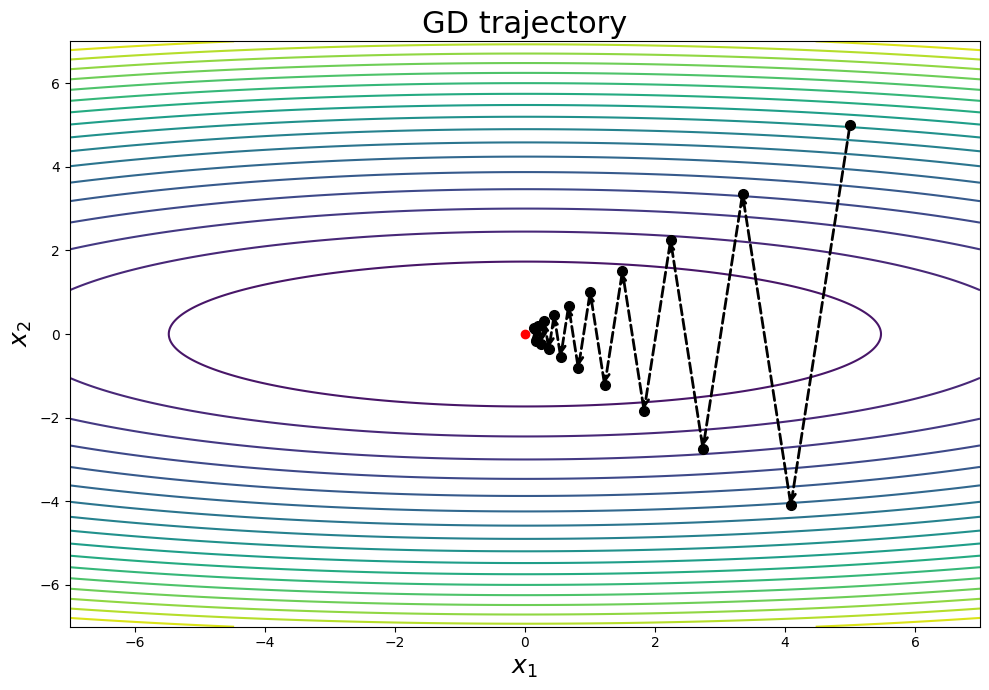

In [77]:
gamma = 2 / (mu + L) # TODO: fix a value for gamma

x, x_obs, f_obs = gradient_descent(x0, eta, gamma, max_iters=max_iters) # TODO: run gradient descent

# TODO: plot the trajectory
plot_trajectory(x_obs)

### Choice of the step-size
Now, fix a value for $\eta > 1$ and run gradient descent with different step-size (including $\gamma = 2/(1 + \eta)$ and $\gamma = 1/\eta$) and observe how performances change.

In [136]:
eta = 10 # TODO: choose a eta > 1

In [137]:
gamma1 = 2 / (1 + eta)
gamma2 = 1 / eta
gamma1, gamma2

(0.18181818181818182, 0.1)

In [138]:
gammas = np.arange(gamma2, gamma1, 0.01) # TODO: define a list of step-sizes
gammas

array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18])

In [139]:
x0 = np.array([5.0, 5.0])
max_iters = 50 # maximum number of iterations
f_values = []


for gamma in gammas:
  _, _, f_obs = gradient_descent(x0, eta, gamma, max_iters=max_iters) # TODO: run gradient descent
  f_values.append(f_obs)

<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_210/2236530375.py:4: SyntaxWarning: invalid escape sequence '\g'
  ax.plot(range(f_values[i].shape[0]), f_values[i], '-', label="$\gamma = $" + str(round(gammas[i], 4)), lw=3)


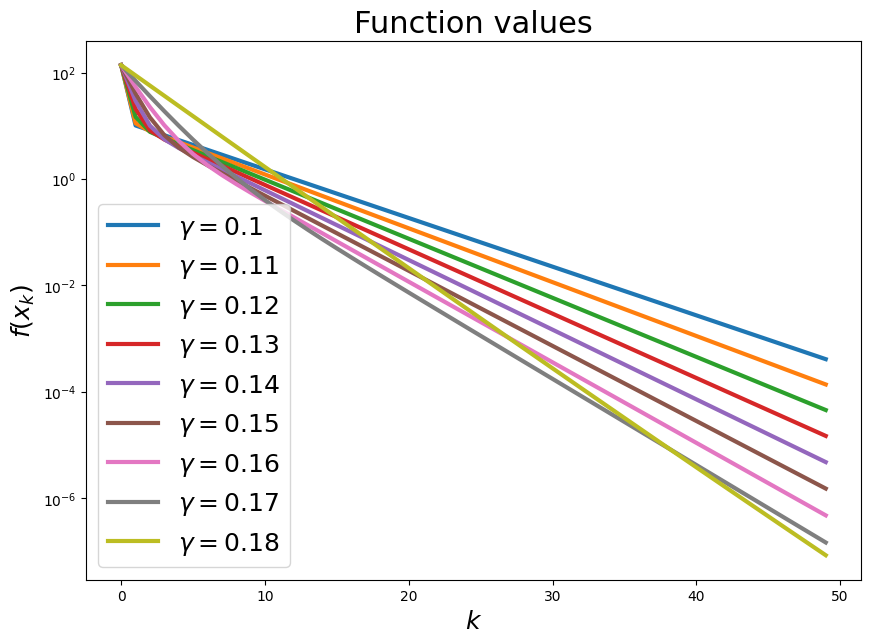

In [140]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_title("Function values", fontsize=22)
for i in range(len(gammas)):
  ax.plot(range(f_values[i].shape[0]), f_values[i], '-', label="$\gamma = $" + str(round(gammas[i], 4)), lw=3)
ax.set_ylabel("$f(x_k)$", fontsize=18)
ax.set_xlabel("$k$", fontsize=18)
ax.set_yscale("log")
ax.legend(fontsize=18)

Repeat the experiment, observing that the following inequality holds
$$
\| x_k \| \leq q(\gamma)^k \| x_0 \| \qquad \text{where} \qquad q(\gamma) = \left\{
        \begin{array}{ll}
            1 - \gamma & \quad \gamma \leq \frac{2}{\eta + 1} \\
            \gamma \eta - 1 & \quad \text{otherwise}
        \end{array}
    \right.
$$
Plot the norm of $x_k$ and $q(\gamma)^k \| x_0 \|$ for every $\gamma$


In [119]:
eta = 10 # TODO: choose a eta > 1

gammas = [1/(10 * eta), 1/(5 * eta),  1/(2* eta), 1/eta,  2/(1 + eta), 2.0/eta]

x0 = np.array([5.0, 5.0])
max_iters = 200 # maximum number of iterations

def q(gamma):
  # TODO: compute and return q(gamma)
  if gamma <= 2 / (eta + 1):
    return 1 - gamma
  else:
    return gamma * eta - 1

def norm_upper_bound(x0, gamma, max_iters):
  ub = np.zeros(max_iters)
  q_gamma = q(gamma)
  x0_norm = norm(x0)
  for k in range(max_iters):
    ub[k] = q_gamma ** k * x0_norm # TODO: compute q(gamma)^k || x_0 ||
  return ub


x_norms = []
upper_bounds = []

for gamma in gammas:
  # TODO: compute the norm upper bound
  ub = norm_upper_bound(x0, gamma, max_iters)
  # TODO: run gradient descent and store the norm of the observed x_k
  _, x_obs, _ = gradient_descent(x0, eta, gamma, max_iters=max_iters) # TODO: run gradient descent
  x_norms.append(norm(x_obs, axis=1))
  upper_bounds.append(ub)

<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:10: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_210/3303803102.py:10: SyntaxWarning: invalid escape sequence '\g'
  axs[i][j].plot(range(x_norms[c].shape[0]), x_norms[c], '-', label="$\gamma = $" + str(round(gammas[c], 4)), lw=3)


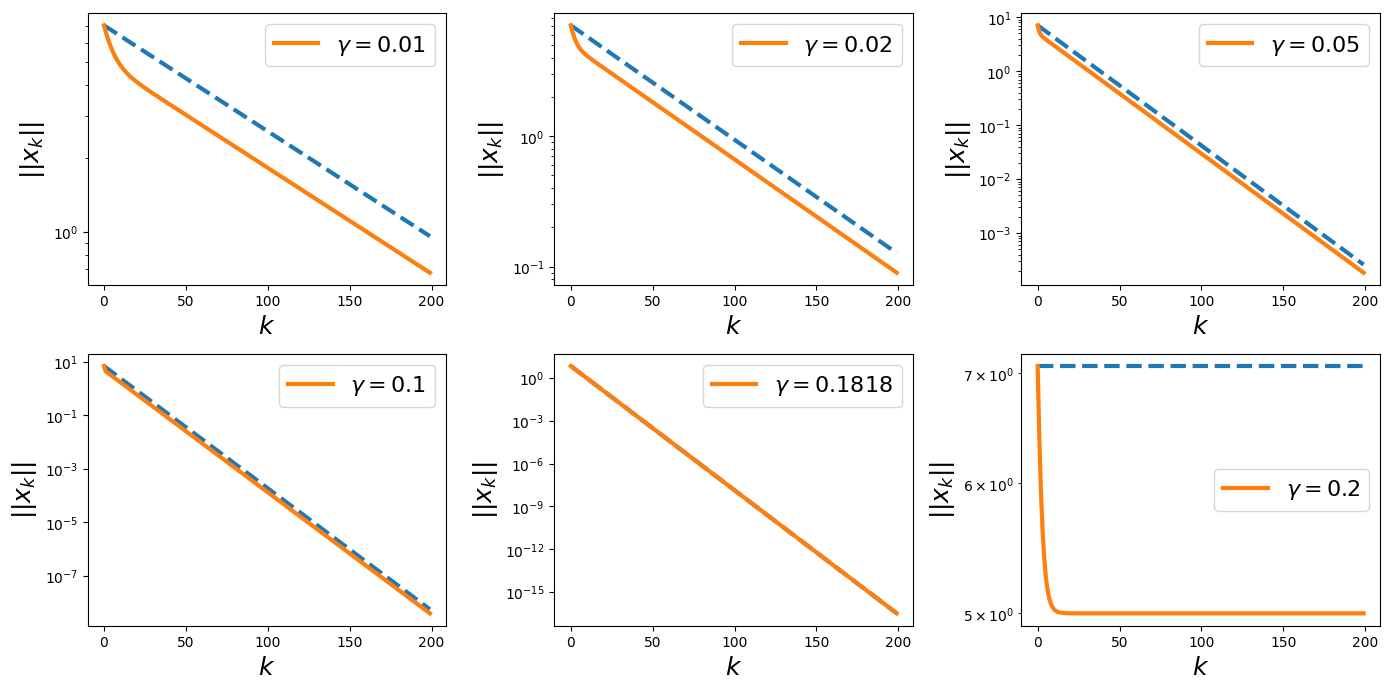

In [120]:
num_rows = 2
num_cols = 3

fig, axs = plt.subplots(num_rows, num_cols, figsize=(14, 7))

c = 0
for i in range(num_rows):
  for j in range(num_cols):
    axs[i][j].plot(range(upper_bounds[c].shape[0]), upper_bounds[c], '--', lw=3)
    axs[i][j].plot(range(x_norms[c].shape[0]), x_norms[c], '-', label="$\gamma = $" + str(round(gammas[c], 4)), lw=3)

    axs[i][j].set_ylabel("$|| x_k ||$", fontsize=18)
    axs[i][j].set_xlabel("$k$", fontsize=18)
    axs[i][j].set_yscale("log")
    axs[i][j].legend(fontsize=16)
    c+= 1
fig.tight_layout()

On the 5-th plot $gamma = 0.1818$ is the optimal value and becomes the upper bound.

# Exercise 2

## Least Square Problem
Let $A \in \mathbb{R}^{n \times d}$ and $y \in \mathbb{R}^n$, consider the problem of minimizing
$$
f(x) = \frac{1}{2} \| Ax - y \|^2.
$$
We consider the setting $n > d$ where (if $\ker(A) = \{0\}$), the problem is $\mu$-strongly convex and gradient descent with $\gamma = 2/(L + \mu)$ has the following convergence rate

$$
\| x_k - x^* \| \leq \Big( \frac{L - \mu}{L + \mu} \Big)^k \| x_0 - x^* \|
$$

First, we define the target function and its gradient

In [144]:
def get_target(A, y):
  def f(x):
    return 1/2 * np.square(norm(A @ x - y, ord=2))

  def grad_f(x):
    # TODO: return gradient of f at x
    return A.transpose() @ (A @ x - y)

  return f, grad_f

Then, we generate a random matrix $A \in \mathbb{R}^{n \times d}$ with $A_{i,j} \sim \mathcal{N}(0, 1)$ and $y \in \mathbb{R}^n$

In [145]:
n = 100
d = 10

x_star = np.ones(d)

A = np.random.randn(n, d) # TODO: generate random (Gaussian) matrix n x d where every entry is sampled from N(0, 1)
y = A @ x_star

Now, we implement a generic version of gradient descent algorithm. This function has the following signature

```
gd(x0, gamma, f, grad_f, max_iters)
```
where:
- `x0` is a numpy array representing the initial point.
- `gamma` is the step-size.
- `f` is the target function.
- `grad_f` is the gradient of the target function.
- `max_iters` is the budget (i.e. number of iterations).

This function will return three elements:
- `x`: the last iterate
- `x_obs` : a matrix (max_iters $\times$ d) containing every iterates
- `f_obs` : a vector containing the function values (i.e. $f(x_k)$ for $k=1, \cdots, $max_iters)


In [147]:
def gd(x0, gamma, f, grad_f, max_iters = 10):
  x = x0.copy()
  x_obs = np.empty((max_iters, x0.shape[0]))
  f_obs = np.empty(max_iters)
  for k in range(max_iters):
    x_obs[k] = x
    f_obs[k] = f(x)
    x = x_obs[k] - gamma * grad_f(x_obs[k])# TODO: compute GD iteration
  return x, x_obs, f_obs


Now, we can the algorithm we implemented before.

In [156]:
x0 = np.random.randn(d) # random initialization
max_iters = 50

eigvals = np.linalg.eigvalsh(A.T @ A) # TODO: get eigenvalues of A^T A
mu, L = min(eigvals), max(eigvals) # TODO: set mu and L

gamma = 2 / (mu + L) # TODO: compute gamma

f, grad_f = get_target(A, y)

x, x_obs, f_vals = gd(x0, gamma, f, grad_f, max_iters = 10) # TODO: run GD
x_norms = norm(x_obs - x_star, axis=1)


Now, plot the function values and the norm of iterates

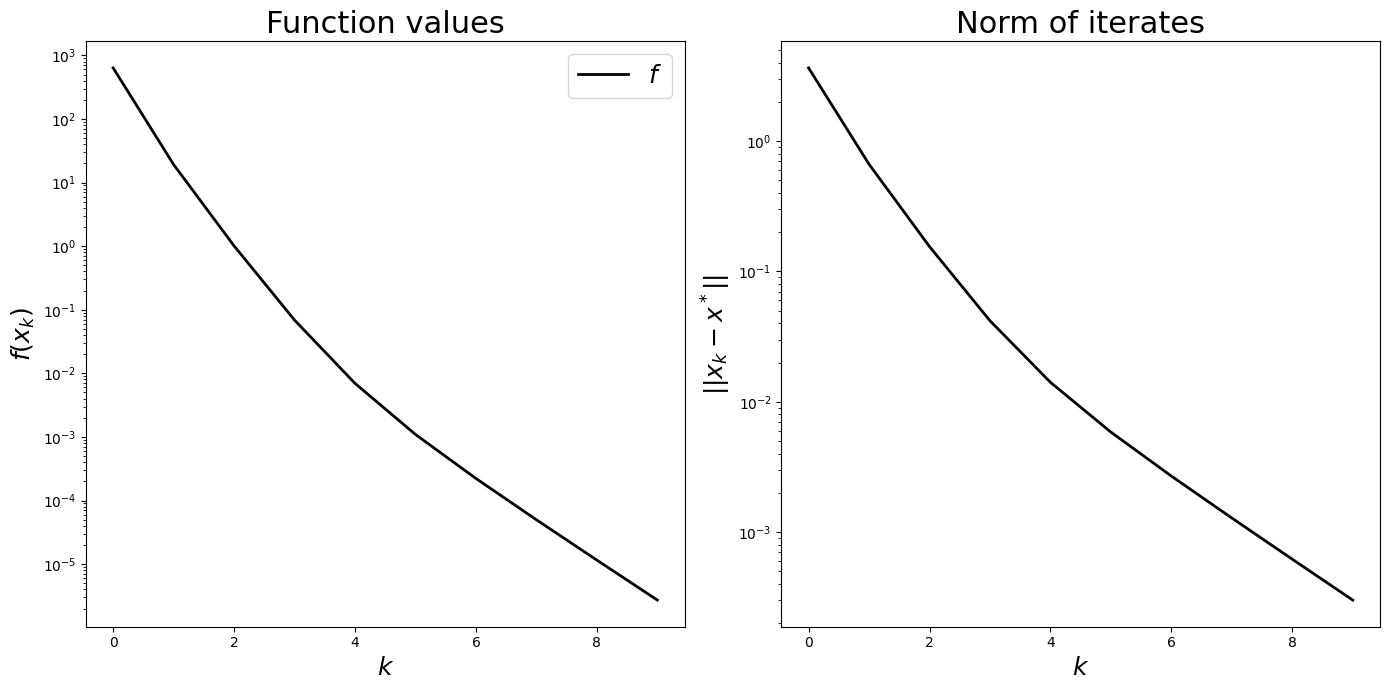

In [157]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.plot(range(f_vals.shape[0]), f_vals, '-', color='black', lw=2, label="$f$")
ax1.set_xlabel("$k$", fontsize=18)
ax1.set_ylabel("$f(x_k)$", fontsize=18)
ax1.set_yscale("log") # set logarithmic scale for y-axis
ax1.legend(fontsize=18)
ax1.set_title("Function values", fontsize=22)

ax2.set_title("Norm of iterates", fontsize=22)
ax2.plot(range(x_norms.shape[0]), x_norms, '-', color='black', lw=2)
ax2.set_xlabel("$k$", fontsize=18)
ax2.set_ylabel("$|| x_k - x^* ||$", fontsize=18)
ax2.set_yscale("log") # set logarithmic scale for y-axis
fig.tight_layout()


Change the stepsize and observe how performance changes

In [158]:
gamma

np.float64(0.00932782347700638)

In [172]:
gamma = 0.0097 # TODO: choose a gamma

f, grad_f = get_target(A, y)

x, x_obs, f_vals = gd(x0, gamma, f, grad_f, max_iters = 10)# TODO: run GD
x_norms = norm(x_obs - x_star, axis=1)

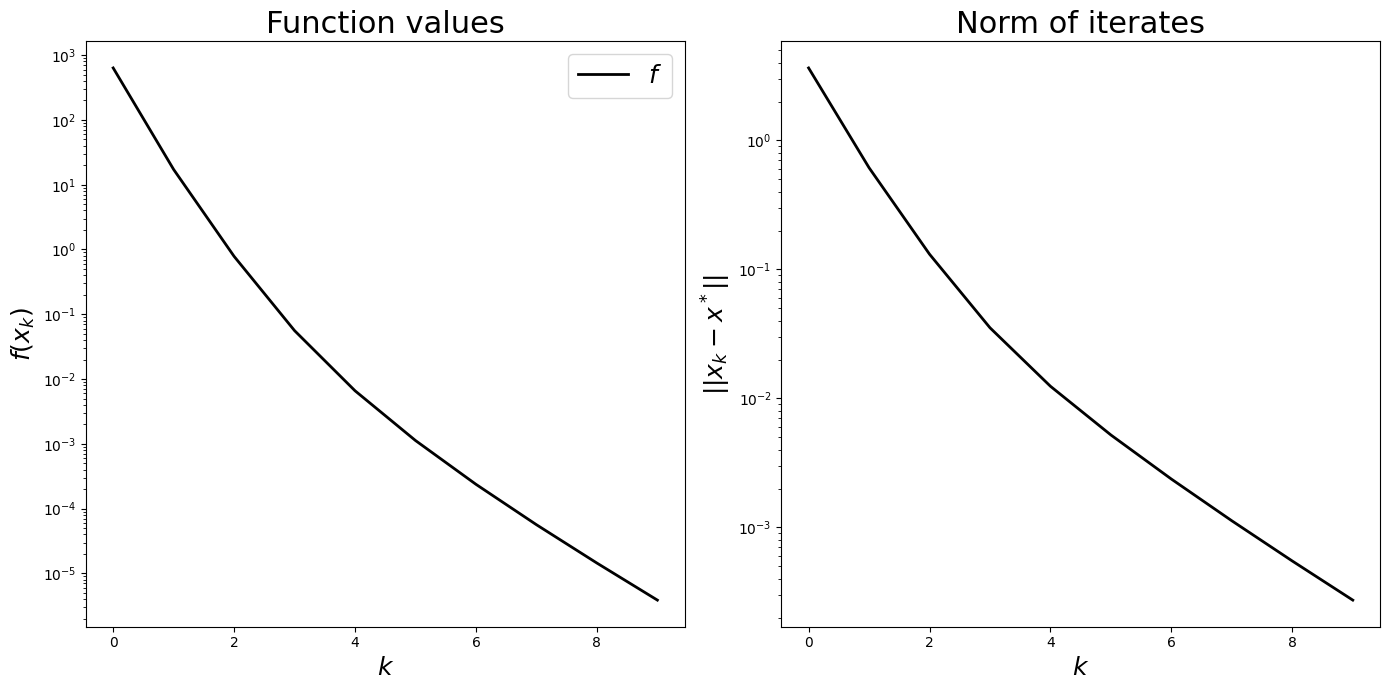

In [173]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.plot(range(f_vals.shape[0]), f_vals, '-', color='black', lw=2, label="$f$")
ax1.set_xlabel("$k$", fontsize=18)
ax1.set_ylabel("$f(x_k)$", fontsize=18)
ax1.set_yscale("log") # set logarithmic scale for y-axis
ax1.legend(fontsize=18)
ax1.set_title("Function values", fontsize=22)

ax2.set_title("Norm of iterates", fontsize=22)
ax2.plot(range(x_norms.shape[0]), x_norms, '-', color='black', lw=2)
ax2.set_xlabel("$k$", fontsize=18)
ax2.set_ylabel("$|| x_k - x^* ||$", fontsize=18)
ax2.set_yscale("log") # set logarithmic scale for y-axis
fig.tight_layout()


Generate $A \in \mathbb{R}^{n \times d}$ randomly with Gaussian entries for $n = 50$ and $d= 100$.

Let ̄$\bar{x} \in \mathbb{R}^{d}$ and set $y=A\bar{x}$. Consider the problem

$$
f(x) = \frac{1}{2} \| Ax - y \|^2.
$$

In this case the matrix is singular, thus the function is not strongly convex. However, the gradient descent procedure converges with the following rate

\begin{equation}
f(x_k) - \min f \leq (1 - \gamma \sigma^2_{min} (2 - \gamma L) )^k (f(x_0) - \min f)
\end{equation}

Compute the minimum ($\sigma_{min}$) and maximum ($\sigma_{max}$) singular values of $A^\intercal A$, and set the stepsize.

Verify the linear convergence behavior.

In [174]:
n, d = 50, 100

A = np.random.randn(n, d)

x_bar = np.ones(d)
y = A @ x_bar

In [178]:
x0 = np.random.randn(d)

ev = np.linalg.eigvalsh(A.T @ A)  # TODO compute eigen values of A.T @ A
sigma_min, L = min(ev), max(ev) # TODO compute min, max eigenvalues of A.T @ A

gamma = 1 / L # TODO: compute gamma

max_iters= 500

f, grad_f = get_target(A, y)

x, x_obs, f_obs = gd(x0, gamma, f, grad_f, max_iters = max_iters) # TODO: run GD

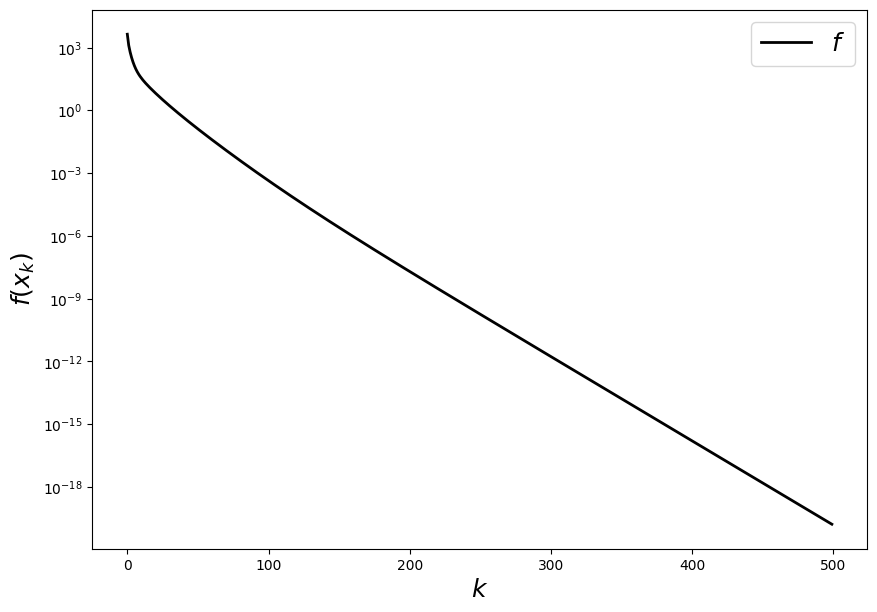

In [180]:
plot_function_values(f_obs)

Repeat the experiment for different value of gamma and observe how $f(x_k)$ changes

In [181]:
gammas = [1/(10 * L), 1/(5 * L), 1/(3 * L), 1/(2 * L), 1/L, 2/(L + sigma_min)]
fun_values = []

for gamma in gammas:
  _, _, f_vals = gd(x0, gamma, f, grad_f, max_iters = max_iters) # TODO: run gradient descent
  fun_values.append(f_vals)


In [184]:
gamma_best = 1 / L
gamma_best

np.float64(0.0034793085159654513)

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_210/4181294255.py:9: SyntaxWarning: invalid escape sequence '\g'
  axs[i][j].plot(range(fun_values[c].shape[0]), fun_values[c], '-', c='orange', label="$\gamma = $" + str(round(gammas[c], 4)), lw=3)


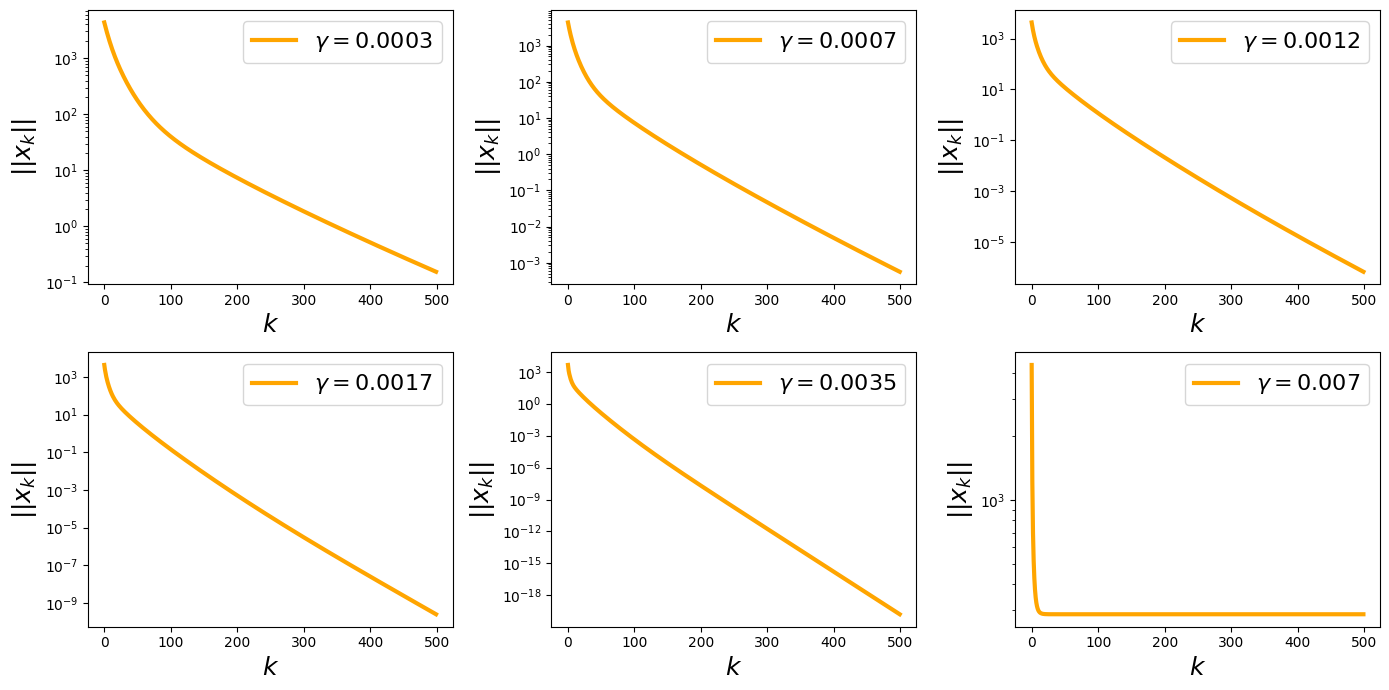

In [182]:
num_rows = 2
num_cols = 3

fig, axs = plt.subplots(num_rows, num_cols, figsize=(14, 7))

c = 0
for i in range(num_rows):
  for j in range(num_cols):
    axs[i][j].plot(range(fun_values[c].shape[0]), fun_values[c], '-', c='orange', label="$\gamma = $" + str(round(gammas[c], 4)), lw=3)

    axs[i][j].set_ylabel("$|| x_k ||$", fontsize=18)
    axs[i][j].set_xlabel("$k$", fontsize=18)
    axs[i][j].set_yscale("log")
    axs[i][j].legend(fontsize=16)
    c+= 1
fig.tight_layout()

# Exercise 3

## A Curve Fitting Problem

Consider the following dictionary of polynomials
$$
\varphi_j(x) = x^{j-1}, \quad j = 1, \dots, m
$$
and the function $f\colon \mathbb{R} \to \mathbb{R}$, $f(x) = \sin(\pi x)$.

We assume that we have access only to a given data set $(x_i, y_i)_{1 \leq i \leq n}$,
where $x_i = -1 + 2(i-1)/(n-1)$ and $y_i = \sin(\pi x_i) + \varepsilon_i$,
and $\varepsilon_i$ is a zero-mean Gaussian noise.

The goal is to find the best approximation of $f$ as $\sum_{j=1}^{m} \beta_j \varphi_j$
on $[-1,1]$, based on the available data set.

To that purpose we consider the least-square approximation obtained by solving the following
minimization problem
$$
\min_{\beta \in \mathbb{R}^m} F(\beta) \qquad F(\beta) = \frac{1}{2} \sum_{i=1}^{n} \left( \sum_{j=1}^{m} \beta_j \varphi_j(x_i) - y_i \right)^2 = \frac{1}{2} \| A \beta - y \|^2,
$$
where
$$
A_{i,j} = \varphi_j(x_i) \qquad \text{and} \qquad y = (y_i)_{1 \leq i \leq n}.
$$

### Tasks
1. Implement the gradient descent method. Plot the solutions and compare with $\sin(\pi x)$ for $m = 20, 50, 100$ and $n = 10, 50, 100$. Try different values of the standard deviation of $\varepsilon$.

2. In case $\varepsilon = 0$, compare the coefficients of the solution with the coefficients in the Taylor expansion of $\sin(\pi x)$:
$$
\sin(\pi x) = \pi x - \frac{\pi^3}{3!} x^3 + \frac{\pi^5}{5!} x^5 - \frac{\pi^7}{7!} x^7 + \frac{\pi^9}{9!} x^9 - \cdots
$$

First build the data set and the matrix $A$.

In [186]:
def data(n, sigma=0.0):
    x = -1 + 2 * np.arange(n) / (n - 1)
    eps = np.random.normal(0, sigma, size=n) if sigma > 0 else np.zeros(n)
    y = np.sin(np.pi * x) + eps
    return x, y

def matrix(x, m):
    n = len(x)
    A = np.zeros((n, m))
    for j in range(m):
        A[:, j] = x ** j       # phi_{j+1}(x) = x^j  (0-indexed)
    return A

Define the objective function and gradient

In [187]:
def f(beta, A, y):
    return 1/2 * np.square(norm(A @ beta - y, ord=2)) # TODO: return the value of the objective function


def grad_f(beta, A, y):
    return A.T @ (A @ beta - y) # TODO: return gradient of f


Implement the gradient descent with constant step size $\gamma = 1/L$

In [193]:
def gradient_descent(A, y, max_iter=1000):
    m = A.shape[1]
    eigenvalues = np.linalg.eigvalsh(A.T @ A)
    L = max(eigenvalues)
    gamma = 1 / L # TODO: compute stepsize

    beta = np.zeros(m)
    beta_obs = np.empty((max_iter, m))
    f_obs = np.empty(max_iter)

    for k in range(max_iter):
        beta_obs[k] = beta
        f_obs[k] = f(beta, A, y)
        beta = beta_obs[k] - gamma * grad_f(beta_obs[k], A, y) # TODO: compute GD iteration

    return beta, beta_obs, f_obs

Solve the curve fitting problem and plot the approximation against $\sin(\pi x)$ for different $m$, $n$ and noise levels

In [203]:
# Fine grid for plotting the true function
x_plot = np.linspace(-1, 1, 500)
y_true = np.sin(np.pi * x_plot)

def evaluate_polynomial(beta, x):
    m = len(beta)
    A_plot = matrix(x, m)
    return A_plot @ beta

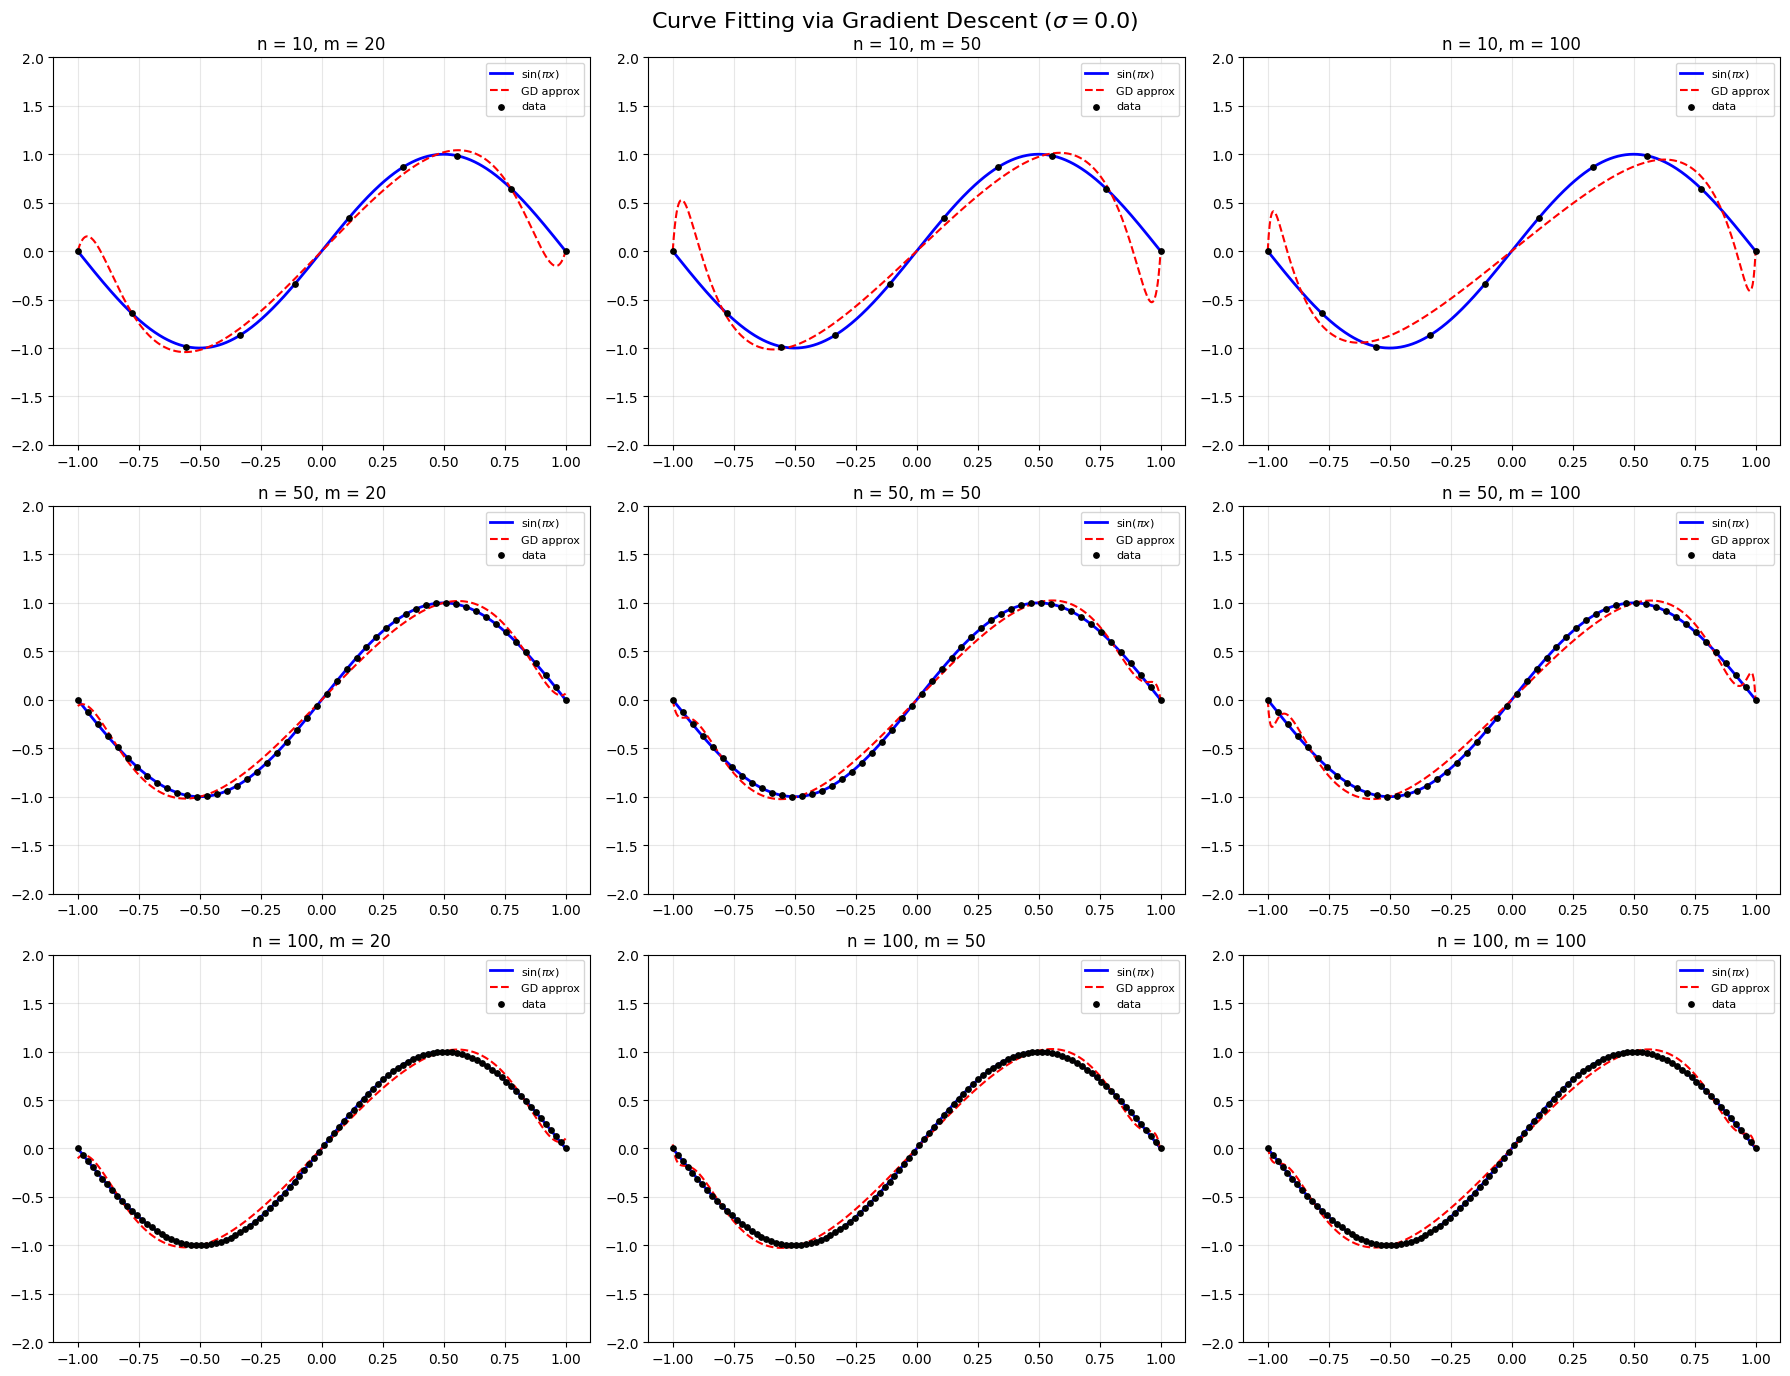

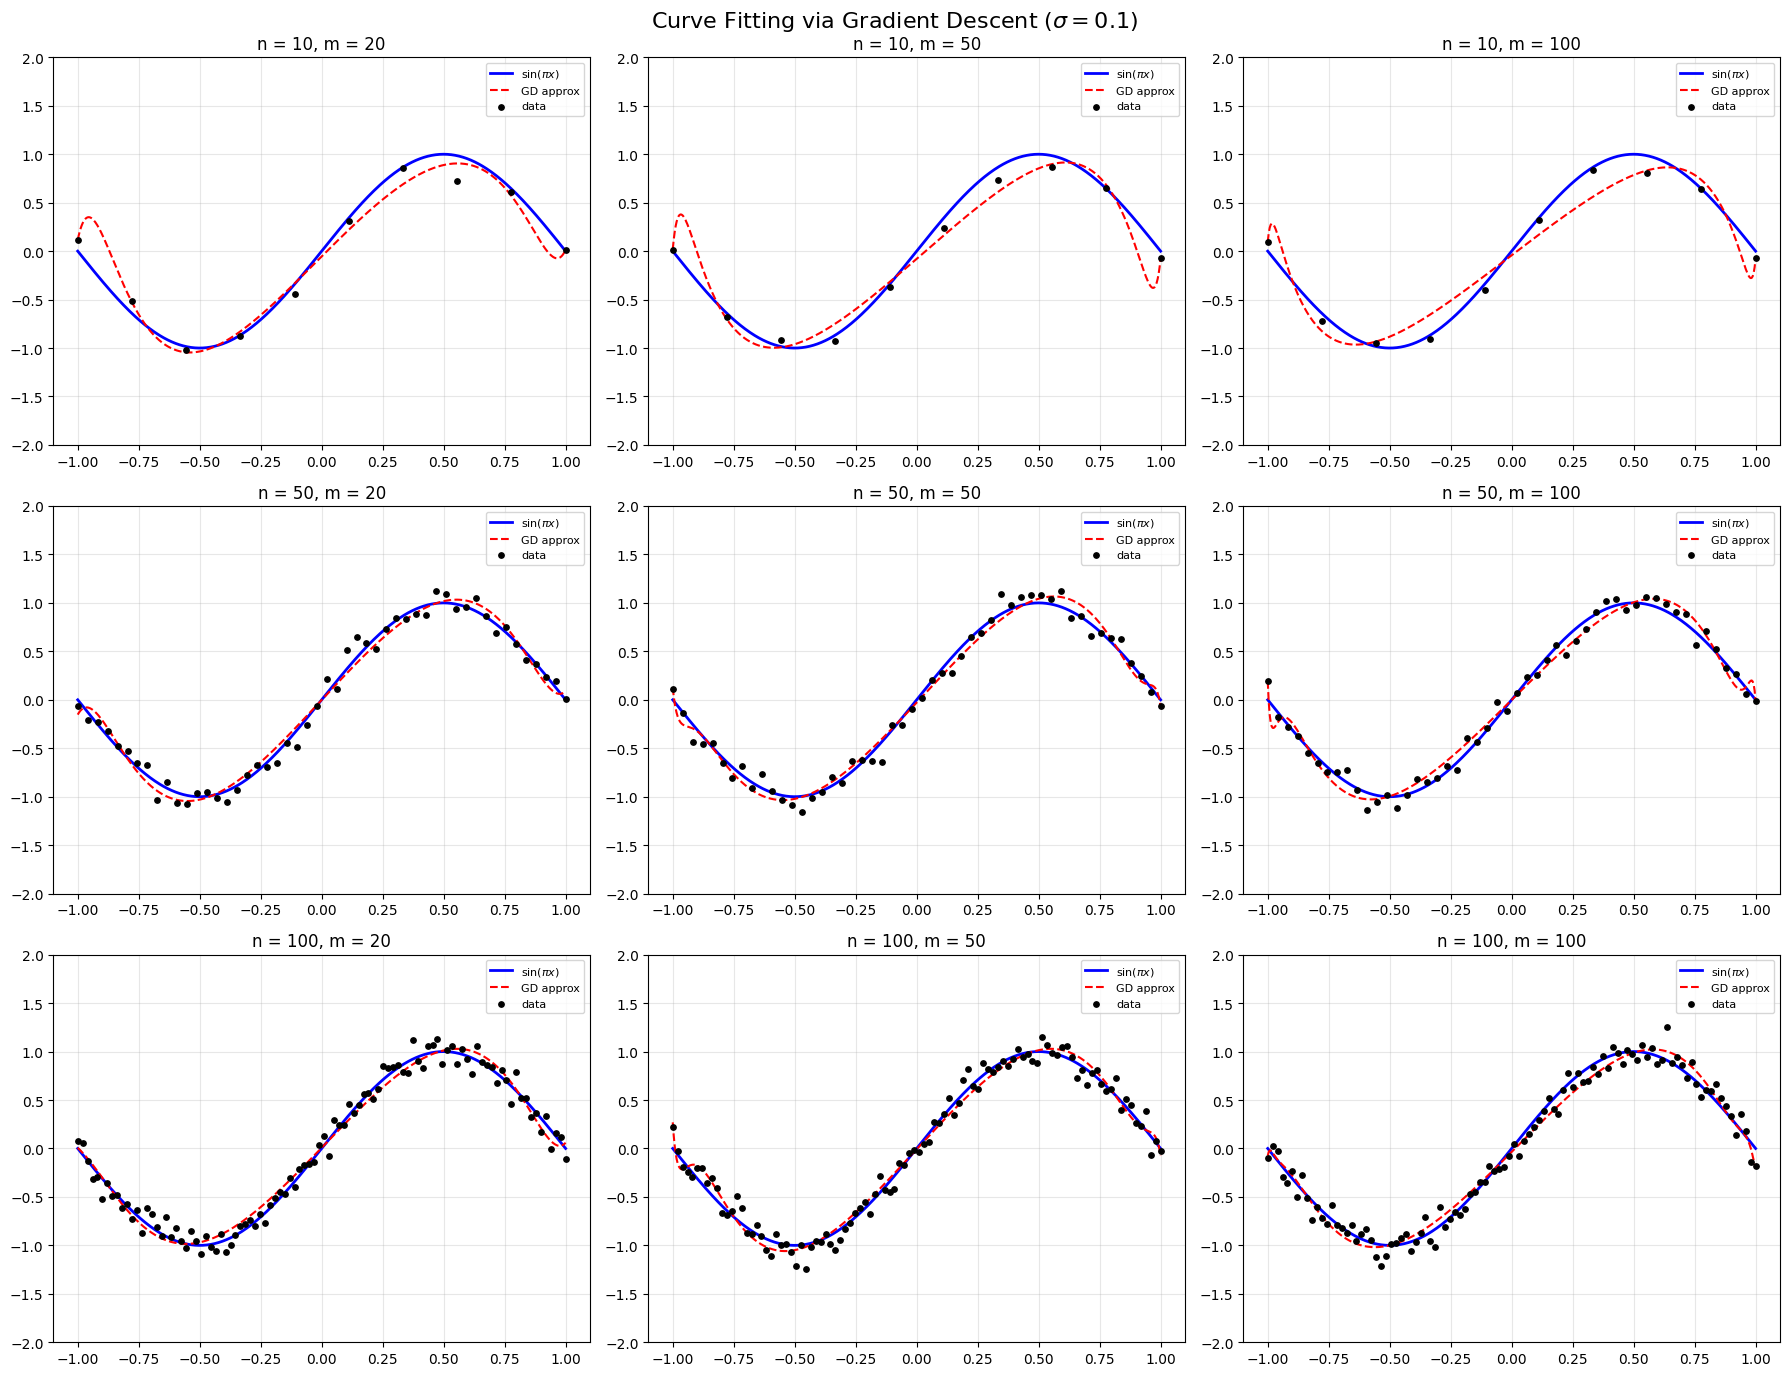

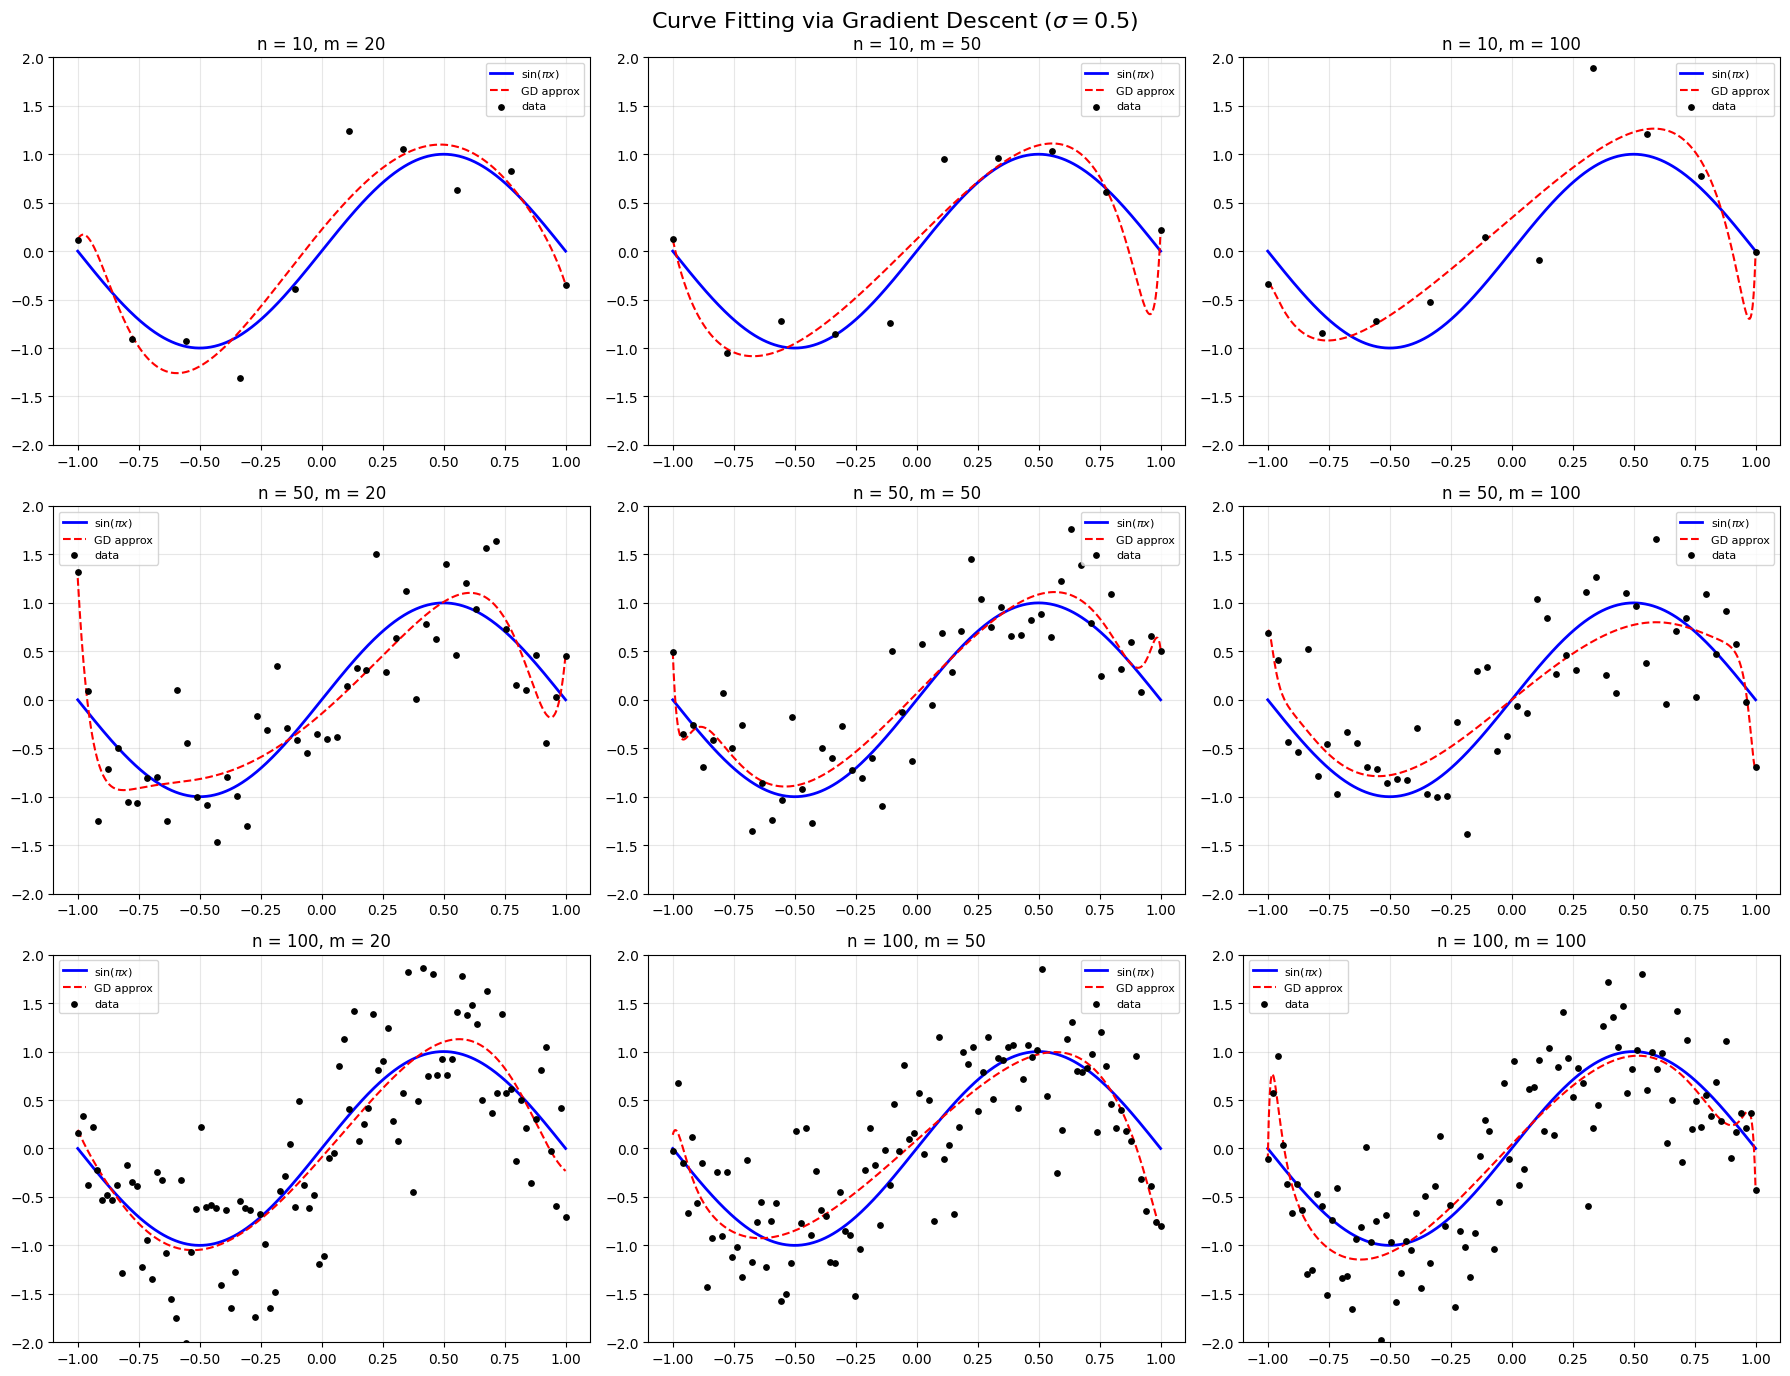

In [205]:
# ---- Parameters to explore ----
n_values = [10, 50, 100]
m_values = [20, 50, 100]
sigma_values = [0.0, 0.1, 0.5]

for sigma in sigma_values:
    fig, axes = plt.subplots(len(n_values), len(m_values), figsize=(18, 14))
    fig.suptitle(f'Curve Fitting via Gradient Descent ($\\sigma = {sigma}$)', fontsize=16)

    for i, n in enumerate(n_values):
        for j, m in enumerate(m_values):
            ax = axes[i, j]

            x_data, y_data = data(n, sigma=sigma) # TODO: generate data with n samples and noise level sigma
            # print(x_data.shape, y_data.shape)

            A = matrix(x_data, m) # TODO: build the design matrix for x_data and m basis functions
            # print(A.shape)

            beta_gd, _, _ = gradient_descent(A, y_data) # TODO: run gradient descent

            y_approx = evaluate_polynomial(beta_gd, x_plot) # TODO: evaluate the polynomial approximation on x_plot

            ax.plot(x_plot, y_true, 'b-', linewidth=2, label='$\\sin(\\pi x)$')
            ax.plot(x_plot, y_approx, 'r--', linewidth=1.5, label='GD approx')
            ax.scatter(x_data, y_data, c='black', s=15, zorder=5, label='data')
            ax.set_title(f'n = {n}, m = {m}')
            ax.set_ylim(-2, 2)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Compare GD coefficients with Taylor expansion ($\varepsilon = 0$)

The Taylor expansion of $\sin(\pi x)$ around $x = 0$ is:
$$
\sin(\pi x) = \sum_{k=0}^{\infty} \frac{(-1)^k \pi^{2k+1}}{(2k+1)!} x^{2k+1} = \pi x - \frac{\pi^3}{3!}x^3 + \frac{\pi^5}{5!}x^5 - \frac{\pi^7}{7!}x^7 + \frac{\pi^9}{9!}x^9 - \dots
$$

In [206]:
from math import factorial

def taylor_coefficients(m):
    coeff = np.zeros(m)
    for j in range(m):
        if j % 2 == 1:  # only odd powers
            k = (j - 1) // 2
            coeff[j] = ((-1) ** k) * (np.pi ** j) / factorial(j)
    return coeff

**Test Case 1**

- $m = 100$
- $n = 50$
- $iterations = 10M$

In [207]:
m = 100 # TODO: choose a value for m
n = 50 # TODO: choose a value for n

x_data, y_data = data(n) # TODO: generate data with n samples and noise level 0.0
A = matrix(x_data, m) # TODO: build the matrix
beta_gd, _ , _ = gradient_descent(A, y_data, max_iter=10000000) # TODO: run gradient descent

taylor_coeff = taylor_coefficients(m) # TODO: compute Taylor coefficients

# Print comparison
print(f"{'j':>3}  {'beta_GD':>14}  {'Taylor coeff':>14}  {'|diff|':>12}")
print("-" * 50)
for j in range(min(m, 15)):
    diff = abs(beta_gd[j] - taylor_coeff[j])
    print(f"{j:3d}  {beta_gd[j]:14.8f}  {taylor_coeff[j]:14.8f}  {diff:12.2e}")

  j         beta_GD    Taylor coeff        |diff|
--------------------------------------------------
  0     -0.00000000      0.00000000      1.54e-17
  1      3.13684996      3.14159265      4.74e-03
  2      0.00000000      0.00000000      3.27e-16
  3     -5.06931658     -5.16771278      9.84e-02
  4     -0.00000000      0.00000000      2.39e-15
  5      2.00212901      2.55016404      5.48e-01
  6      0.00000000      0.00000000      3.25e-15
  7      0.47542360     -0.59926453      1.07e+00
  8      0.00000000      0.00000000      1.89e-15
  9     -0.39594133      0.08214589      4.78e-01
 10      0.00000000      0.00000000      5.82e-16
 11     -0.38228879     -0.00737043      3.75e-01
 12     -0.00000000      0.00000000      1.35e-15
 13     -0.12139870      0.00046630      1.22e-01
 14     -0.00000000      0.00000000      6.23e-15


**Test Case 2**

- $m = 50$
- $n = 100$
- $iterations = 10M$

In [208]:
m = 50 # TODO: choose a value for m
n = 100 # TODO: choose a value for n

x_data, y_data = data(n) # TODO: generate data with n samples and noise level 0.0
A = matrix(x_data, m) # TODO: build the matrix
beta_gd, _ , _ = gradient_descent(A, y_data, max_iter=10000000) # TODO: run gradient descent

taylor_coeff = taylor_coefficients(m) # TODO: compute Taylor coefficients

# Print comparison
print(f"{'j':>3}  {'beta_GD':>14}  {'Taylor coeff':>14}  {'|diff|':>12}")
print("-" * 50)
for j in range(min(m, 15)):
    diff = abs(beta_gd[j] - taylor_coeff[j])
    print(f"{j:3d}  {beta_gd[j]:14.8f}  {taylor_coeff[j]:14.8f}  {diff:12.2e}")

  j         beta_GD    Taylor coeff        |diff|
--------------------------------------------------
  0      0.00000000      0.00000000      2.58e-18
  1      3.13792843      3.14159265      3.66e-03
  2     -0.00000000      0.00000000      5.21e-16
  3     -5.08916648     -5.16771278      7.85e-02
  4      0.00000000      0.00000000      4.45e-15
  5      2.09476143      2.55016404      4.55e-01
  6     -0.00000000      0.00000000      9.73e-15
  7      0.35417216     -0.59926453      9.53e-01
  8      0.00000000      0.00000000      1.47e-15
  9     -0.43997972      0.08214589      5.22e-01
 10      0.00000000      0.00000000      8.45e-15
 11     -0.32269510     -0.00737043      3.15e-01
 12      0.00000000      0.00000000      5.15e-15
 13     -0.03044630      0.00046630      3.09e-02
 14     -0.00000000      0.00000000      1.57e-15


**Test Case 3**

- $m = 100$
- $n = 100$
- $iterations = 1000$

In [209]:
m = 100 # TODO: choose a value for m
n = 100 # TODO: choose a value for n

x_data, y_data = data(n) # TODO: generate data with n samples and noise level 0.0
A = matrix(x_data, m) # TODO: build the matrix
beta_gd, _ , _ = gradient_descent(A, y_data, max_iter=1000) # TODO: run gradient descent

taylor_coeff = taylor_coefficients(m) # TODO: compute Taylor coefficients

# Print comparison
print(f"{'j':>3}  {'beta_GD':>14}  {'Taylor coeff':>14}  {'|diff|':>12}")
print("-" * 50)
for j in range(min(m, 15)):
    diff = abs(beta_gd[j] - taylor_coeff[j])
    print(f"{j:3d}  {beta_gd[j]:14.8f}  {taylor_coeff[j]:14.8f}  {diff:12.2e}")

  j         beta_GD    Taylor coeff        |diff|
--------------------------------------------------
  0      0.00000000      0.00000000      2.43e-18
  1      2.59689945      3.14159265      5.45e-01
  2     -0.00000000      0.00000000      1.72e-16
  3     -2.05101391     -5.16771278      3.12e+00
  4      0.00000000      0.00000000      7.90e-17
  5     -1.17856879      2.55016404      3.73e+00
  6      0.00000000      0.00000000      1.10e-16
  7     -0.41552463     -0.59926453      1.84e-01
  8      0.00000000      0.00000000      1.40e-16
  9     -0.00373040      0.08214589      8.59e-02
 10      0.00000000      0.00000000      1.58e-16
 11      0.18640066     -0.00737043      1.94e-01
 12      0.00000000      0.00000000      7.35e-17
 13      0.25632309      0.00046630      2.56e-01
 14      0.00000000      0.00000000      6.71e-17
